<style>
  body { zoom: 1.2; }
</style>
<div style="width:100%; box-sizing:border-box; overflow:hidden; background-image: linear-gradient(rgba(0,0,0,0.22), rgba(0,0,0,0.28)), url('blog_figures/PNG1.jpg'); background-size: cover; background-position: center 60%; border-radius: 6px; padding: 3rem 2rem; color: #ffffff;">
  <h1 style="margin:0 0 0.7rem 0; font-size:2.1rem; text-shadow: 0 2px 8px rgba(0,0,0,0.7); white-space:normal; overflow-wrap:break-word;">Identifying Land Swap Opportunities to Improve Habitat Connectivity at Pawnee National Grassland</h1>
  <p style="margin:0 0 0.5rem 0; font-weight:bold; text-shadow: 0 1px 6px rgba(0,0,0,0.7); white-space:normal; overflow-wrap:break-word;">Kayleigh Ward, Max Warnock, and Nate Hofford | Earth Data Analytics Certificate Program</p>
  <p style="margin:0; font-style:italic; text-shadow: 0 1px 6px rgba(0,0,0,0.7); white-space:normal; overflow-wrap:break-word;">This analysis identifies and ranks parcel exchanges that would reduce land fragmentation and increase contiguous federal land at Pawnee National Grassland, Weld County, Colorado.</p>
  <p style="margin:1.2rem 0 0 0; font-size:0.72em; text-shadow: 0 1px 4px rgba(0,0,0,0.8); white-space:normal;">Photo credit: <a href="https://www.fs.usda.gov/r02/arp/recreation/pawnee-national-grassland" style="color:#ffffff;">U.S. Forest Service</a></p>
</div>

---

## Improving ecosystem connectivity on a fragmented landscape


<div style="float:right; width:320px; max-width:38%; margin: 0 0 1.2rem 1.5rem; box-sizing:border-box; overflow:hidden;">
  <figure style="margin:0;">
    <img src="blog_figures/PNG2.jpeg" width="320" style="width:320px; max-width:100%; height:auto; border-radius:4px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3;">Pawnee National Grassland<br>Photo credit: <a href="https://www.coloradolifemagazine.com/blog/post/pawnee-national-grassland-colorado" style="color:#666;">Joshua Hardin Photography</a></figcaption>
  </figure>
</div>


For more than 150 years, the great plains of North America have been heavily fragmented by agriculture, ranching, development, and energy production. As a result, efforts to preserve prairie ecosystems are often hindered by this "checkerboard" of different land ownership types. A prime example of this can be found at the Pawnee National Grassland in northeastern Colorado. This grassland is comprised of a patchwork of federal land managed by the U.S. Forest Service, as well as state and private land.  

Fragmented ownership limits the Forest Service's ability to manage the grassland as a unified ecosystem. Control of invasive species, grazing allotments, and wildlife habitat management are more difficult to coordinate when federal parcels are isolated from one another by intervening private or state land. A land swap can help solve this issue by consolidating disparate federal land. Land swaps are voluntary exchanges in which the Forest Service acquires a non-federal parcel and releases a federal parcel of comparable size and value.

This project, conducted in partnership with the non-profit Grasslands Unlimited, develops a geospatial workflow to identify and rank land swap opportunities that would reduce fragmentation and increase the contiguous federal land area at Pawnee National Grassland.


<div style="clear:both;"></div>

## Visualization of the fragmented grassland ownership


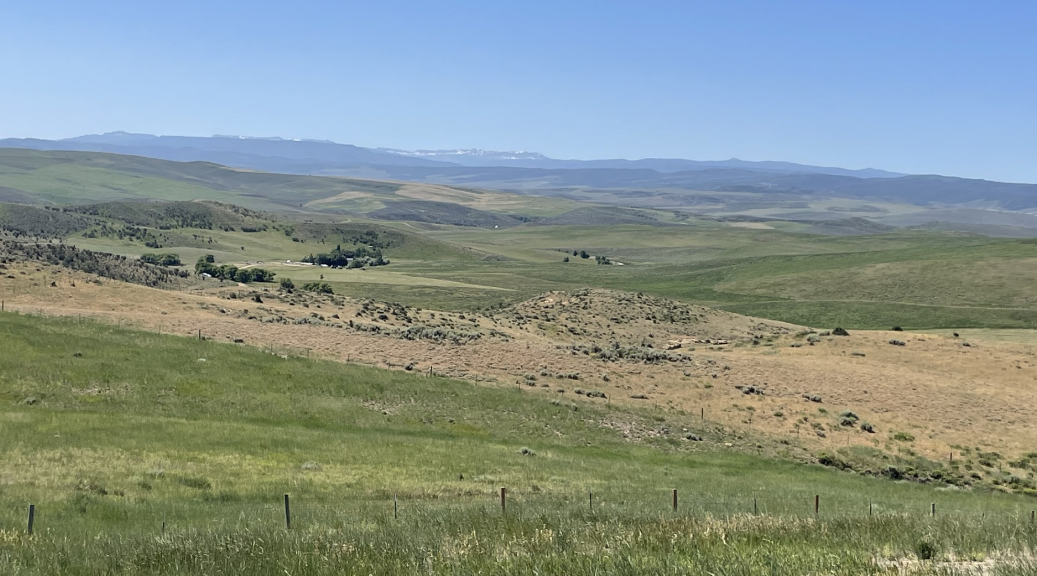

In [5]:
import base64
import html as html_lib
from pathlib import Path
from IPython.display import HTML

_boundary_html = Path("../../figures/boundary_figures/pawnee_boundary_plot.html").read_text(encoding="utf-8")
_fragmented_land_b64 = base64.b64encode(
    Path("blog_figures/fragmented_land.png").read_bytes()
).decode("ascii")

display(HTML(f'''
<div style="display:flex; gap:16px; flex-wrap:wrap; max-width:1180px; margin:0 auto;">
  <figure style="flex:0 1 820px; min-width:280px; margin:0;">
    <iframe srcdoc="{html_lib.escape(_boundary_html, quote=True)}" scrolling="no"
      style="width:100%; height:365px; border:none; border-radius:6px; display:block; overflow:hidden;"></iframe>
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.4rem; line-height:1.3;">
      Map of the Pawnee National Grassland boundaries in Weld County, Colorado, showing the fragmented ownership of federal (blue) and state (red) land within the western and eastern units. The remaining uncolored land is privately owned.
    </figcaption>
  </figure>
  <figure style="flex:1 1 300px; min-width:240px; margin:0;">
    <img src="data:image/png;base64,{_fragmented_land_b64}"
      style="width:100%; height:365px; object-fit:cover; border-radius:6px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.4rem; line-height:1.3;">
      Example of how fragmented habitat can lead to non-uniform land management.<br>Photo credit: Nate Hofford
    </figcaption>
  </figure>
</div>
'''))

## Why land fragmentation matters

Landscape fragmentation is a recognized threat to biodiversity and ecosystem function across the world ([Haddad et al., 2015](https://www.science.org/doi/10.1126/sciadv.15000520)). Fragmentation can reduce biodiversity, alter nutrient cycling, inhibit wildlife movement, and change plant successional patterns (Haddad et al., 2015; [Anderson et al., 2023](https://www.pnas.org/doi/10.1073/pnas.2204434119)). At Pawnee National Grassland, fragmentation affects multiple ecologically important species and land management processes.

Black-tailed prairie dogs are considered a keystone species in shortgrass prairie systems. Their colonies support more than 150 other species, including burrowing owls, ferruginous hawks, and black-footed ferrets ([Kotliar et al., 2006](https://pubs.usgs.gov/publication/87264)). Prairie dog colonies function best when they can expand and recolonize across connected patches, and isolated federal parcels surrounded by private land can limit that capacity. Similarly, pronghorn antelope require large, connected movement corridors across the grassland landscape ([Millspaugh et al., 2021](https://fwp.mt.gov/binaries/content/assets/fwp/conservation/pronghorn/p-r-report---montana-pronghorn-project---2021.pdf)).

From a management perspective, contiguous federal blocks simplify the coordination of invasive species management (which can involve herbicide application), grazing rotations, and wildlife habitat management. A study by [Powers et al., 2022](https://doi.org/10.1016/j.biocon.2022.109557) demonstrated that reconnecting stranded public lands (isolated federal parcels surrounded by private ownership) produced a win-win scenario for both conservation management on federal land and private land contiguity. Targeted land swaps are one mechanism to achieve that reconnection without requiring new federal land purchases.

## Land swap identification methods
#### *Contiguous area and exposure*

<div style="float:right; width:500px; max-width:60%; margin: 0 0 1.2rem 1.5rem; box-sizing:border-box; overflow:hidden;">
  <figure style="margin:0;">
    <img src="blog_figures/contig_area_and_exposure.png" width="500" style="width:500px; max-width:100%; height:auto; border-radius:4px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3;"><em>Visualization of contiguous area and boundary exposure.</em></figcaption>
  </figure>
</div>

Parcel data for Weld County were downloaded from the [county's public GIS API](https://gishub.weldgov.com/datasets/37d03225dab04760b4fd9f5f531d313e_0/explore) and clipped to the Pawnee National Grassland master boundary. Each parcel was classified as federal, state, or private based on the owner name field in the county dataset. Federal parcels that shared meaningful boundaries with each other (not just corners) were identified and labeled as "patches". The area in square kilometers of these patches is the measure of contiguous area of federal land. 

For each patch, we also calculated an exposure metric that represents how contained the patch is. The goal of this metric is to identify differences between patches that are well consolidated, and patches that are spread out and mixed with non-federal land. The exposure metric is a ratio of the total boundary lengths of the patch that touch federal land vs. non-federal land. The more of a patch's edges that are adjacent to other federal parcels rather than outside land, the more contiguous and unified that patch is. Additionally for each patch, an exposure value was calculated as the percentage of its total boundary length that borders non-federal land, with a lower percentage indicating a more compact, internally consolidated patch of federal ownership.

**Contiguous area** — the total acreage of all federal parcels in a connected patch:
\[
\text{Contiguous Area (acres)} = \text{parcel 1 acres} + \text{parcel 2 acres} + \cdots
\]

**Patch exposure** — the percentage of the patch's total boundary that borders non-federal land:
\[
\text{Exposure (%)} = \frac{\text{outer boundary length}}{\text{outer boundary length} + \text{shared edges between federal parcels}} \times 100
\]

<div style="clear:both;"></div>

## Identification of acquire and release parcels

Each land swap needs an acquire and release parcel which are identified using several criteria. The basic logic is as follows: Acquire parcels are classified as either state or privately owned land that is directly adjacent to a federal patch. Release parcels are federally owned land that is generally disconnected from other federal parcels.

<figure style="margin:1.2rem auto 0; width:550px; max-width:100%;">
  <img src="blog_figures/acquire_and_release.png" width="550" style="width:550px; max-width:100%; height:auto; border-radius:4px; display:block; margin:0 auto;">
  <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3; text-align:center;"><em>Criteria for eligible acquire (non-federal) and release (federal) parcels in a proposed land swap.</em></figcaption>
</figure>

## Ranking the swaps
After identifying the acquire and release candidate pairs, we rank them based on several factors. 

#### *Bridge swaps rank highest*
Bridge swaps involve an acquire parcel that connects two already existing patches of federal land. This new parcel "bridges" the gap and creates a much more contiguous area. Within the bridge swap category, wider bridge connections, and connections that bridge larger federal areas are ranked higher. 

**Bridge connection score** — a 0–100% score that equally weights how much acreage the bridge connects and how wide the physical connection is:
\[
\text{Bridge Score} = \frac{1}{2}\left(\frac{\text{acres gained}}{\text{max acres gained (any bridge)}} + \frac{\text{connection width (m)}}{\text{max connection width (any bridge)}}\right) \times 100\%
\]
Each component is first expressed as a fraction of the best-performing bridge proposal, so a very wide but small-gain bridge and a very large but narrow bridge are compared on equal footing.



<div style="display:flex; gap:16px; flex-wrap:wrap; justify-content:center;">
  <figure style="flex:1 1 260px; max-width:32%; margin:0;">
    <img src="blog_figures/bridge_swap1.png" style="width:100%; height:auto; border-radius:4px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3;"><em>A bridge swap connects two existing federal patches with an acquired parcel, forming one larger contiguous block.</em></figcaption>
  </figure>
  <figure style="flex:1 1 260px; max-width:32%; margin:0;">
    <img src="blog_figures/bridge_swap2.png" style="width:100%; height:auto; border-radius:4px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3;"><em>Wider bridge connections are ranked more favorably than narrow ones.</em></figcaption>
  </figure>
  <figure style="flex:1 1 260px; max-width:32%; margin:0;">
    <img src="blog_figures/bridge_swap3.png" style="width:100%; height:auto; border-radius:4px; display:block;">
    <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3;"><em>Bridges that connect to larger federal patches are ranked more favorably.</em></figcaption>
  </figure>
</div>

#### *Non-bridge swaps*

For swaps that don't bridge two separate patches, ranking is driven primarily by how much the swap lowers the receiving patch's exposure metric. A swap decreases exposure whenever the acquired parcel adds more shared boundary with existing federal parcels than the released parcel takes away. The larger that decrease, the more the patch is being consolidated into a single compact block, and proposals producing the biggest exposure reduction are ranked highest among non-bridge swaps.

**Exposure reduction** — the change in patch exposure after the swap (reported in percentage points):
\[
\text{Exposure reduction (pp)} = \text{exposure before swap (%)} - \text{exposure after swap (%)}
\]

<figure style="margin:1.2rem auto 0; width:340px; max-width:100%;">
  <img src="blog_figures/patch_exposure_decrease.png" width="340" style="width:340px; max-width:100%; height:auto; border-radius:4px; display:block; margin:0 auto;">
  <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3; text-align:center;"><em>The same patch after two candidate swaps, showing the resulting percent and mileage of exposed edge remaining.</em></figcaption>
</figure>

#### *Release parcel ranking*

As a final tiebreaker, proposals are also ranked by comparing each parcel's own exposure: how much of the acquired parcel's boundary already touches federal land, versus how much of the released parcel's boundary was interior to its own patch before the swap. A proposal ranks higher when the released parcel was only slightly enclosed to begin with while the acquired parcel is already largely surrounded by federal land. That combination gains the most enclosure for the least loss in contiguity.

**Acquire parcel enclosure** — how much of the non-federal parcel's boundary already touches the federal patch:
\[
\text{Acquire enclosure} = \frac{\text{boundary touching federal land}}{\text{total parcel boundary length}}
\]

**Release parcel enclosure** — how much of the released federal parcel's boundary was shared with other federal parcels before the swap:
\[
\text{Release enclosure} = \frac{\text{boundary shared inside its federal patch}}{\text{total parcel boundary length}}
\]

**Enclosure delta** — the tiebreaker; a positive value means the acquired parcel is more enclosed by federal land than the parcel being released:
\[
\text{Enclosure delta} = \text{acquire enclosure} - \text{release enclosure}
\]

<figure style="margin:1.2rem auto 0; width:340px; max-width:100%;">
  <img src="blog_figures/release_identification.png" width="340" style="width:340px; max-width:100%; height:auto; border-radius:4px; display:block; margin:0 auto;">
  <figcaption style="font-size:0.82em; color:#666; margin-top:0.3rem; line-height:1.3; text-align:center;"><em>Comparing two candidate release parcels: the one with fewer exposed sides is favored.</em></figcaption>
</figure>

## Results  

**Highest Ranked Swaps**

The swap identification and ranking shows that the top five ranked swaps create a bridge between two of the largest federal patches on the grassland. These top five proposals all identify the same acquire parcel, but suggest different release parcels in the vicinity. These swaps have a bridge score of 81%, meaning they provide a large connection between the two large federal patches. The shared acquire parcel is a 649.2-acre private parcel (ID 029729000009) that would form a 4,064.9 m wide connection between the patches. Before any of these swaps, the receiving patch's boundary exposure is 58.0%. The ranking does not consider land value, but allows the user to identify swaps that are similar in value, such as proposal #3. 

<div style="display:flex; gap:10px; flex-wrap:wrap; justify-content:center; max-width:1100px; margin:1.2rem auto 0;">
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/result1.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#1</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/result2.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#2</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/result3.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#3</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/result4.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#4</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/result5.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#5</figcaption>
  </figure>
</div>

<div style="overflow-x:auto; max-width:1100px; margin:1rem auto 0;">
  <table style="border-collapse:collapse; width:100%; font-size:0.76em; color:#333; white-space:nowrap;">
    <thead>
      <tr style="background:#f2f2f2; text-align:left;">
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">#</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Bridge score</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Exposure change (pp / mi)</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">New exposure</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Contiguity gain</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Federal value change (acquire &minus; release)</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Enclosure &Delta;</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Release parcel</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Area diff.</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Distance</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Release patch effect</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">1</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">81.53%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;0.68 pp (&minus;3.43 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">57.3%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+14,491.3 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;$305,468</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">24.74 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029725000004 (620.3 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">4.4%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">6.32 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">Same patch (already reflected above)</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">2</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">81.53%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;0.45 pp (&minus;2.49 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">57.6%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+14,492.4 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;$303,507</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">12.63 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">020734000004 (619.3 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">4.6%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">8.76 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">Same patch (already reflected above)</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">3</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">81.49%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;0.15 pp (+1.00 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">57.9%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+14,480.9 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;$2,166</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">18.72 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029706000002 (630.7 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">2.8%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">6.62 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">PATCH_020: 0.171 &rarr; 0.142</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">4</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">81.46%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;0.15 pp (+1.00 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">57.9%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+14,471.5 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;$305,492</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">12.78 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029915000005 (640.1 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">1.4%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">7.19 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">PATCH_005: 0.337 &rarr; 0.338</td>
      </tr>
      <tr>
        <td style="padding:6px 8px;">5</td>
        <td style="padding:6px 8px;">81.46%</td>
        <td style="padding:6px 8px;">&minus;0.15 pp (+1.00 mi)</td>
        <td style="padding:6px 8px;">57.9%</td>
        <td style="padding:6px 8px;">+14,471.9 ac</td>
        <td style="padding:6px 8px;">&minus;$303,506</td>
        <td style="padding:6px 8px;">12.48 pp</td>
        <td style="padding:6px 8px;">029927000006 (639.8 ac)</td>
        <td style="padding:6px 8px;">1.4%</td>
        <td style="padding:6px 8px;">6.44 km</td>
        <td style="padding:6px 8px;">PATCH_004: 0.346 &rarr; 0.347</td>
      </tr>
    </tbody>
  </table>
</div>


**Swaps that Improve Federal *and* State Land Contiguity**

The five proposals below all identify swap locations that would improve both federal and state contiguity. All five reduce the receiving federal patch's boundary exposure from a starting point of 65.4%. These swaps are ranked primarily by how much exposure to non-federal land decreases rather than by bridge score.



<div style="display:flex; gap:10px; flex-wrap:wrap; justify-content:center; max-width:1100px; margin:1.2rem auto 0;">
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/state_result1.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#67</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/state_result2.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#94</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/state_result3.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#105</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/state_result4.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#107</figcaption>
  </figure>
  <figure style="flex:1 1 180px; max-width:19%; margin:0;">
    <img src="blog_figures/state_result5.png" style="width:100%; height:auto; border-radius:4px; display:block; border:1px solid #ddd;">
    <figcaption style="font-size:0.78em; color:#666; margin-top:0.2rem; text-align:center; font-weight:bold;">#108</figcaption>
  </figure>
</div>

<div style="overflow-x:auto; max-width:1100px; margin:1rem auto 0;">
  <table style="border-collapse:collapse; width:100%; font-size:0.76em; color:#333; white-space:nowrap;">
    <thead>
      <tr style="background:#f2f2f2; text-align:left;">
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">#</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Exposure change (pp / mi)</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">New exposure</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Contiguity gain</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Federal value change (acquire &minus; release)</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Enclosure &Delta;</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Acquire parcel</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Release parcel</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Area diff.</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Distance</th>
        <th style="padding:6px 8px; border-bottom:2px solid #ccc;">Release patch effect</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">67</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;5.23 pp (&minus;4.00 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">60.1%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+0.5 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+$3,022</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">75.18 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">045716000001 (640.6 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029915000005 (640.1 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">0.1%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">9.86 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">PATCH_005: 0.337 &rarr; 0.338</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">94</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;3.62 pp (&minus;4.00 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">61.8%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+2.7 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+$511</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">50.01 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029936000003 (642.5 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">045721000002 (639.8 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">0.4%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">8.07 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">Same patch (already reflected above)</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">105</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;3.44 pp (&minus;2.02 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">61.9%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+22.1 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+$53</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">62.36 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029936000003 (642.5 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029725000004 (620.3 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">3.4%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">9.72 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">PATCH_001: 0.420 &rarr; 0.425</td>
      </tr>
      <tr>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">107</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">&minus;3.44 pp (&minus;2.02 mi)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">61.9%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+2.3 ac</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">+$29</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">50.41 pp</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029936000003 (642.5 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">029915000005 (640.1 ac)</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">0.4%</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">5.82 km</td>
        <td style="padding:6px 8px; border-bottom:1px solid #eee;">PATCH_005: 0.337 &rarr; 0.338</td>
      </tr>
      <tr>
        <td style="padding:6px 8px;">108</td>
        <td style="padding:6px 8px;">&minus;3.44 pp (&minus;2.02 mi)</td>
        <td style="padding:6px 8px;">61.9%</td>
        <td style="padding:6px 8px;">&minus;0.5 ac</td>
        <td style="padding:6px 8px;">+$2,022</td>
        <td style="padding:6px 8px;">50.99 pp</td>
        <td style="padding:6px 8px;">029936000003 (642.5 ac)</td>
        <td style="padding:6px 8px;">029735000002 (643.0 ac)</td>
        <td style="padding:6px 8px;">0.1%</td>
        <td style="padding:6px 8px;">8.00 km</td>
        <td style="padding:6px 8px;">PATCH_001: 0.420 &rarr; 0.423</td>
      </tr>
    </tbody>
  </table>
</div>
<p style="font-size:0.78em; color:#666; margin-top:0.4rem;">

## Interactive swap explorer

https://maxwarnock.github.io/Pawnee-Grasslands-Project/

The full set of ranked proposals is available in an interactive parcel swap explorer, linked above. Every proposal can be viewed directly on a map alongside the ranked list. Clicking any proposal highlights the specific acquire and release parcels involved and shows the details of that swap.

The tool also lets you narrow the list down to the swaps you care about. You can filter to a specific federal patch, show only bridge swaps that connect two separate patches, or limit results to swaps within the same patch versus across different patches. Sliders let you set a minimum exposure reduction, a maximum allowable difference in acreage between the two parcels, and a maximum distance between them, so you can tighten or loosen the criteria used in this analysis. Checkboxes let you exclude any proposal where the acquired or released parcel intersects active oil and gas infrastructure, or restrict results to swaps that would also connect a private or state landowner's existing holdings nearby.

## Explorer demo video

In [6]:
from IPython.display import HTML

display(HTML('''
<div style="max-width:820px; margin:1.2rem auto 0;">
  <iframe src="https://drive.google.com/file/d/1n8pdOSYb7mUPyQaC2d_pY0JKztk32nBS/preview"
    width="100%" height="461" style="border:none; border-radius:6px; display:block;" allow="autoplay" allowfullscreen></iframe>
  <p style="font-size:0.82em; color:#666; text-align:center; margin-top:0.4rem;">
    <em>Demo walkthrough of the interactive parcel swap explorer. If the video doesn't load, <a href="https://drive.google.com/file/d/1n8pdOSYb7mUPyQaC2d_pY0JKztk32nBS/view">watch it directly on Google Drive</a>.</em>
  </p>
</div>
'''))

## Conclusion

This project shows that even a heavily fragmented landscape like the Pawnee National Grassland has hundreds of quantifiable swap opportunities for consolidation. By systematically identifying and ranking potential parcel exchanges, this analysis gives the U.S. Forest Service and its partners a concrete starting point for reconnecting isolated federal land into larger, more manageable blocks through land swaps.

One of the most important features of the land swap tool is the ability to identify mutually benefitical land swaps. The tool identifies swap proposals where the released federal parcel would also connect to a private landowner's or the state's existing holdings nearby, meaning the other party in the trade often comes away with a more contiguous block of their own. This mutual benefit is frequently what makes a land swap worth negotiating in the first place. Other features, such is the ability to filter out active oil and gas locations, the ability to view parcels by market value, and area difference statistics between the swaps are also essential for identifying viable land swap candidates.

The ecological benefit as a result of these land swaps is just as important. Fragmented ownership makes it harder to manage prairie dog colonies, support pronghorn migration corridors, and coordinate invasive species control and grazing rotations. The swap proposals identified in our algorithm each represent ways in which the grassland's federal land can become more consolidated to support better conservation and land management practices on the grasslands. 


## Future work
This land swap identification algorithm could easily be applied to other grasslands across the country or world. It could also be used in any other applications where the goal is to maximize contiguity of different land ownership types. 

## Limitations

The current swap ranking is based mainly on bridge score value, edge exposure decrease and spatial contiguity gain. Data to inform more ecologically minded swaps has been intentionally left out due to its spatial sparseness across the landscape, and because land managers on the grassland will have a more accurate ecological understanding of the area. We encourage the users of this tool to supplement these swap recommendations with field surveys to ensure there is ecological value behind these land swap decisions. Additionally, there may be other logistics and factors that could make some of these proposed land swaps difficult to implement. 

## Additional Resources

The full project repository, including all notebooks, data processing scripts, and documentation, is available on GitHub:

**[github.com/maxwarnock/Pawnee-Grasslands-Project](https://github.com/maxwarnock/Pawnee-Grasslands-Project)**

The project dataset is archived on Zenodo:

**DOI: [10.5281/zenodo.19864164](https://doi.org/10.5281/zenodo.19864164)**

**Project partner:** Grasslands Unlimited   
https://www.grasslandsunlimited.org/

---

## References

Anderson, M. G., Clark, M., Olivero, A. P., Barnett, A. R., Hall, K. R., Cameron, M. W., Auer, M., Samu, M., Udell, B., Schloss, C., & Cameron, D. R. (2023). A resilient and connected network of sites to sustain biodiversity under a changing climate. *Proceedings of the National Academy of Sciences, 120*(7), e2204434119. https://doi.org/10.1073/pnas.2204434119

Baynard, C. W., Mjachina, K., Richardson, R. D., Schupp, R. W., Lambert, J. D., & Chibilyev, A. A. (2017). Energy development in Colorado's Pawnee National Grasslands: Mapping and measuring the disturbance footprint of renewables and non-renewables. *Environmental Management, 59*, 995–1016. https://doi.org/10.1007/s00267-017-0846-z

Haddad, N. M., Brudvig, L. A., Clobert, J., Davies, K. F., Gonzalez, A., Holt, R. D., Lovejoy, T. E., Sexton, J. O., Austin, M. P., Collins, C. D., Cook, W. M., Damschen, E. I., Ewers, R. M., Foster, B. L., Jenkins, C. N., King, A. J., Laurance, W. F., Levey, D. J., Margules, C. R., Melbourne, B. A., Nicholls, A. O., Orrock, J. L., Song, D.-X., & Townshend, J. R. (2015). Habitat fragmentation and its lasting impact on Earth's ecosystems. *Science Advances, 1*(2), e1500052. https://doi.org/10.1126/sciadv.1500052

Hazlett, D. L. (1998). *Vascular plant species of the Pawnee National Grassland* (General Technical Report RMRS-GTR-17). U.S. Department of Agriculture, Forest Service, Rocky Mountain Research Station. https://research.fs.usda.gov/download/treesearch/25015.pdf

Kotliar, N. B., Miller, B. J., Reading, R. P., & Clark, T. W. (2006). The prairie dog as a keystone species. In J. Hoogland (Ed.), *Conservation of the black-tailed prairie dog: Saving North America's western grasslands* (pp. 53–64). Island Press. https://pubs.usgs.gov/publication/87264

Millspaugh, J., DeVoe, J., & Proffitt, K. (2021). *Pronghorn movement and population ecology project: 2021 annual interim report* (Federal Aid in Wildlife Restoration Grant W-176-R). Montana Fish, Wildlife & Parks and University of Montana. https://fwp.mt.gov/binaries/content/assets/fwp/conservation/pronghorn/p-r-report---montana-pronghorn-project---2021.pdf

Powers, L. C., Larsen, A. E., Leonard, B., & Plantinga, A. J. (2022). Reconnecting stranded public lands is a win-win for conservation and people. *Biological Conservation, 270*, 109557. https://doi.org/10.1016/j.biocon.2022.109557

Rhoads, D., & Rhoads, L. (n.d.). *History of the Pawnee National Grassland*. U.S. Forest Service. https://www.fs.usda.gov/media/71487

Riitters, K. H. (2013). Fragmentation of forest, grassland, and shrubland. In K. M. Potter & B. L. Conkling (Eds.), *Forest health monitoring: National status, trends, and analysis 2010* (Gen. Tech. Rep. SRS-GTR-176, pp. 53–65). U.S. Department of Agriculture, Forest Service, Southern Research Station.

U.S. Forest Service. (n.d.). *The national grasslands story*. U.S. Department of Agriculture. https://www.fs.usda.gov/managing-land/national-forests-grasslands/national-grasslands/about-us

Weld County GIS. (2026). *Weld County real property parcels* [Dataset]. Weld County GIS Hub. https://gishub.weldgov.com/datasets/37d03225dab04760b4fd9f5f531d313e_0/explore

## Supplemental: Formal Metric Definitions

The following are the mathematical equations of each metric used in the ranking algorithm, for technical reference.

#### *Contiguous area*
\[
A_{\text{patch}} = \sum_{i \,\in\, \text{patch}} A_i
\]
where \(A_i\) is the area of federal parcel \(i\) in acres.

#### *Patch interior fraction and exposure*
\[
f_{\text{interior}} = \frac{\displaystyle\sum_{(i,j)\,\in\, E} L_{ij}}{\displaystyle\sum_{(i,j)\,\in\, E} L_{ij} \;+\; P_{\text{outer}}}
\]
\[
\text{Exposure (\%)} = (1 - f_{\text{interior}}) \times 100
\]
where \(L_{ij}\) is the shared boundary length between adjacent federal parcels \(i\) and \(j\), \(E\) is the set of touching parcel pairs within the patch, and \(P_{\text{outer}}\) is the total outer perimeter of the dissolved patch.

#### *Bridge connection score*
\[
S_{\text{bridge}} = \frac{1}{2}\left(\frac{G}{\max_{\text{bridges}}(G)} + \frac{W}{\max_{\text{bridges}}(W)}\right)
\]
where \(G\) is the contiguity gain in acres (net area traded plus the size of the smaller bridged patch, capped at acquire parcel size) and \(W\) is the total shared boundary length in meters between the acquired parcel and all patches it bridges.

#### *Exposure reduction*
\[
\Delta\text{Exposure} = (f_{\text{interior, old}} - f_{\text{interior, new}}) \times 100 \;\text{pp}
\]
where \(f_{\text{interior, new}}\) is recalculated from the updated patch geometry after adding the acquired parcel and removing the released parcel.

#### *Parcel-level enclosure*
\[
f_{\text{acq}} = \frac{L_{\text{acq} \cap \text{patch}}}{P_{\text{acq}}} \qquad f_{\text{rel}} = \frac{L_{\text{rel, interior}}}{P_{\text{rel}}}
\]
\[
\Delta_{\text{enclosure}} = f_{\text{acq}} - f_{\text{rel}}
\]
where \(L_{\text{acq} \cap \text{patch}}\) is the length of the acquire parcel boundary touching the receive patch, \(L_{\text{rel, interior}}\) is the length of the release parcel boundary interior to its patch, and \(P\) denotes total parcel perimeter.